# 05 — Readouts and finite shots: what measurement leaves behind

Everything so far used exact probabilities. A device produces **samples**, and
between the circuit and any downstream use sits a choice the earlier
notebooks foreshadowed: the *readout* — which invariant summary of the
empirical distribution you keep. This notebook compares three, on irregular
graphs, under realistic shot budgets:

| Readout | Definition | Dimension ($n=14$, bimodal) |
|---|---|---|
| **R0** | globally sorted probabilities (truncated head) | 500 kept of 16,384 |
| **R1** | total mass at each Hamming weight | 15 |
| **R2** | mass on each joint occupancy of the degree classes | 64 |

The program's three-level vocabulary, made operational: a target can be
present **representationally** (embeddings differ), accessible **linearly**
(an exact-state probe reads it out), and accessible **statistically** (the
same probe still works from $2^{k}$ samples). The levels are not
interchangeable — and this notebook exhibits a readout where the gap between
the last two is total.

**Population and target.** 200 distinct connected graphs with the fixed
bimodal degree sequence $(2^{\times 7}, 4^{\times 7})$, sampled
deterministically. With the degree sequence fixed, the entire joint-degree
mixing freedom is one integer — the number of cross-degree edges
$m_{24}$ (both same-degree counts are affine in it) — so the target is the
cleanest degree-mixing coordinate an irregular census offers. The circuit is
the family's flat-preparation X-mixer arm at canonical angles; the
preparation-dependence of every conclusion is measured explicitly at the end.


In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

import quic
from quic import theory  # noqa: F401  (used by later notebooks)

# Consistent, colorblind-safe styling across the notebook series (Okabe-Ito).
OKABE = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73",
         "vermillion": "#D55E00", "purple": "#CC79A7", "sky": "#56B4E9",
         "black": "#000000"}
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "font.size": 10.5, "axes.titlesize": 11.5, "figure.constrained_layout.use": True,
})

report = quic.selfcheck()


selfcheck passed: 14 check groups, worst qiskit/numpy disagreement 2.78e-16


In [2]:
import time
import warnings

import pandas as pd

from quic import circuit_probabilities
from quic.datasets import degree_stratum
from quic.finite_shots import recovery_curves, ridge_probe_r2, total_variation
from quic.graph_features import cross_degree_edge_count
from quic.readouts import (readout_R0, readout_R1, readout_R2, sector_structure,
                           validate_R2_implementations)

warnings.filterwarnings("ignore")
t0 = time.time()

DEGREE_SEQUENCE = [2] * 7 + [4] * 7
graphs = degree_stratum(DEGREE_SEQUENCE, count=200, seed=7)
adjacency = [nx.to_numpy_array(g) for g in graphs]
target = np.array([cross_degree_edge_count(g) for g in graphs], dtype=float)
structures = [sector_structure(a.sum(axis=1).astype(int)) for a in adjacency]

print(f"{len(graphs)} graphs, degree sequence {sorted(DEGREE_SEQUENCE)}")
print(f"mixing target m24: range {int(target.min())}..{int(target.max())}, "
      f"sd {target.std():.2f}")
print(f"R2 sector count: {structures[0]['n_sectors']} "
      f"(= 8 x 8 joint occupancies)  [{time.time()-t0:.0f}s]")

200 graphs, degree sequence [2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 4]
mixing target m24: range 4..14, sd 1.99
R2 sector count: 64 (= 8 x 8 joint occupancies)  [1s]


## Exact distributions, and the readout audit

Exact statevector probabilities for all 200 graphs, and the package's R2
audit on this stratum's sector structure (dual independent implementations,
binomial sector cardinalities, conservation).


In [3]:
PROBS = {}
for prep in ("flat", "hadamard", "degree"):
    PROBS[prep] = [circuit_probabilities(a, prep=prep) for a in adjacency]
validate_R2_implementations(PROBS["flat"][0], adjacency[0].sum(axis=1).astype(int))
print(f"exact distributions for 3 preparations x 200 graphs; R2 dual-implementation "
      f"audit passed  [{time.time()-t0:.0f}s]")

exact distributions for 3 preparations x 200 graphs; R2 dual-implementation audit passed  [3s]


## Finite-shot recovery, paired by construction

For each budget $2^{10} \ldots 2^{18}$ and each of 6 replicates, one
empirical distribution is sampled per graph and **all three readouts are
applied to the same sample** — scores are paired across readouts, so their
differences are estimated without between-sample noise. The probe is the
series-standard held-out ridge; exact-state ceilings run first. Everything is
seeded and reproduces bit-for-bit.


In [4]:
SHOT_LADDER = tuple(1 << k for k in (10, 12, 14, 16, 18))
RESULT = recovery_curves(PROBS["flat"], target, structures=structures,
                         shot_ladder=SHOT_LADDER, n_replicates=6, seed=0)
print("exact-state ceilings (flat prep):",
      {k: round(v, 4) for k, v in RESULT["ceilings"].items()})
for kind in ("R0", "R1", "R2"):
    means = {int(np.log2(s)): round(float(np.mean(v)), 3)
             for s, v in RESULT["curves"][kind].items()}
    print(f"  {kind} mean R2 by log2(shots): {means}")
print(f"[{time.time()-t0:.0f}s]")

exact-state ceilings (flat prep): {'R0': 1.0, 'R1': 0.9997, 'R2': 1.0}
  R0 mean R2 by log2(shots): {10: -0.033, 12: -0.03, 14: 0.086, 16: 0.728, 18: 0.957}
  R1 mean R2 by log2(shots): {10: -0.031, 12: -0.044, 14: -0.02, 16: 0.01, 18: 0.228}
  R2 mean R2 by log2(shots): {10: -0.03, 12: 0.127, 14: 0.494, 16: 0.804, 18: 0.944}
[12s]


**Read the ceilings first.** At exact state, *all three* readouts probe the
mixing target essentially perfectly — including R1, whose 15 Hamming
coordinates encode it linearly at machine precision. Whatever separates the
readouts below is therefore purely statistical: same circuit, same
information, same probe, different survival under sampling.


In [5]:
# Paired differences with deterministic bootstrap CIs.
def bootstrap_ci(differences, seed_key, n_boot=2000):
    rng = np.random.default_rng(abs(hash(seed_key)) % (2**32))
    diffs = np.asarray(differences)
    boots = np.array([diffs[rng.integers(0, len(diffs), len(diffs))].mean()
                      for _ in range(n_boot)])
    return diffs.mean(), np.quantile(boots, 0.025), np.quantile(boots, 0.975)

paired = []
for shots in SHOT_LADDER:
    for baseline in ("R0", "R1"):
        d = (np.array(RESULT["curves"]["R2"][shots])
             - np.array(RESULT["curves"][baseline][shots]))
        mean, lo, hi = bootstrap_ci(d, ("flat", shots, baseline))
        paired.append({"log2_shots": int(np.log2(shots)),
                       "comparison": f"R2-{baseline}", "mean": mean,
                       "ci_low": lo, "ci_high": hi})
paired = pd.DataFrame(paired)
print(paired.to_string(index=False, float_format=lambda v: f"{v:+.3f}"))

 log2_shots comparison   mean  ci_low  ci_high
         10      R2-R0 +0.003  -0.011   +0.021
         10      R2-R1 +0.002  -0.010   +0.014
         12      R2-R0 +0.156  +0.128   +0.183
         12      R2-R1 +0.171  +0.137   +0.203
         14      R2-R0 +0.408  +0.379   +0.453
         14      R2-R1 +0.514  +0.493   +0.529
         16      R2-R0 +0.076  +0.051   +0.102
         16      R2-R1 +0.794  +0.758   +0.828
         18      R2-R0 -0.013  -0.021   -0.005
         18      R2-R1 +0.716  +0.699   +0.736


## The figure

Left: recovery curves (per-replicate points, mean lines). R2 is the only
readout with useful recovery in the middle of the ladder ($R^2 \approx 0.5$
at $2^{14}$, where R0 is at $0.09$ and R1 at zero); R0 catches up at the top
of the ladder; **R1 never reaches half its ceiling at any tested budget** —
at $2^{18}$, with R0 and R2 both $\approx 0.95$, R1 has climbed only to
$0.23$ despite an exact ceiling of $1.0$. Right: the paired advantage of R2
over each baseline with bootstrap 95% intervals — large through the middle
of the ladder against R0, large *everywhere past* $2^{10}$ against R1, and
honestly slightly negative against R0 at $2^{18}$, where both are near
ceiling.


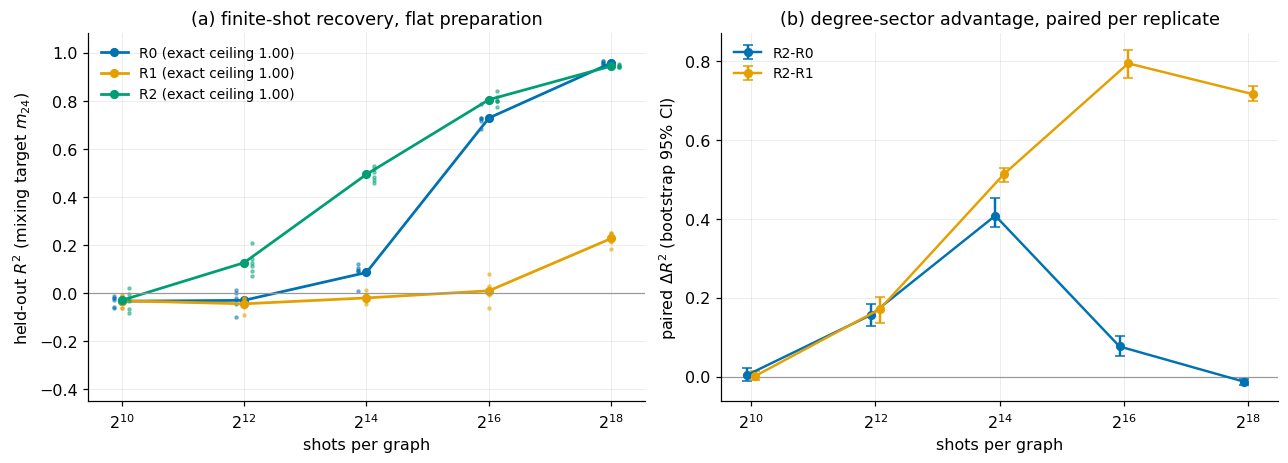

In [6]:
import os

RCOLOR = {"R0": OKABE["blue"], "R1": OKABE["orange"], "R2": OKABE["green"]}
exponents = [int(np.log2(s)) for s in SHOT_LADDER]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 4.1))
for kind in ("R0", "R1", "R2"):
    means = [np.mean(RESULT["curves"][kind][s]) for s in SHOT_LADDER]
    for s, e in zip(SHOT_LADDER, exponents):
        vals = RESULT["curves"][kind][s]
        ax1.plot([e + {"R0": -0.13, "R1": 0.0, "R2": 0.13}[kind]] * len(vals), vals,
                 ".", color=RCOLOR[kind], alpha=0.45, markersize=4)
    ax1.plot(exponents, means, "-o", color=RCOLOR[kind], linewidth=1.8,
             markersize=5, label=f"{kind} (exact ceiling "
             f"{RESULT['ceilings'][kind]:.2f})")
ax1.axhline(0, color="0.6", linewidth=0.8)
ax1.set_xticks(exponents, [f"$2^{{{e}}}$" for e in exponents])
ax1.set_xlabel("shots per graph")
ax1.set_ylabel("held-out $R^2$ (mixing target $m_{24}$)")
ax1.set_title("(a) finite-shot recovery, flat preparation")
ax1.set_ylim(-0.45, 1.08)
ax1.legend(frameon=False, fontsize=9, loc="upper left")

for comparison, color in [("R2-R0", OKABE["blue"]), ("R2-R1", OKABE["orange"])]:
    rows = paired[paired.comparison == comparison]
    ax2.errorbar(rows.log2_shots + (-0.07 if comparison == "R2-R0" else 0.07),
                 rows["mean"],
                 yerr=[rows["mean"] - rows.ci_low, rows.ci_high - rows["mean"]],
                 fmt="o-", color=color, linewidth=1.6, markersize=5,
                 capsize=3, label=comparison)
ax2.axhline(0, color="0.6", linewidth=0.8)
ax2.set_xticks(exponents, [f"$2^{{{e}}}$" for e in exponents])
ax2.set_xlabel("shots per graph")
ax2.set_ylabel("paired $\\Delta R^2$ (bootstrap 95% CI)")
ax2.set_title("(b) degree-sector advantage, paired per replicate")
ax2.legend(frameon=False, fontsize=9)

os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/finite_shot_readouts.png")
plt.show()

## Why R1 fails: estimation fidelity is not the bottleneck

The obvious excuse for R1 would be estimation error — but R1 is the *easiest*
readout to estimate. Measuring each readout's own total-variation error
(empirical readout vs exact readout, mean over graphs) shows R1 converging
fastest at every budget, exactly as its 15 dimensions suggest — while its
target recovery lags both other readouts by an order of magnitude through
most of the ladder. The failure is **semantic**: with a flat preparation the
two degree classes enter the encoder symmetrically, and pooling by Hamming
weight sums over the class split that carries the mixing information,
leaving only delicate cancellations that exact arithmetic resolves and
sampling noise buries. R2 keeps the split — its advantage is alignment with
degree structure, not dimensionality (64 coordinates vs 15, both minuscule
against $2^{14}$). This is the series' sharpest instance of exact
accessibility failing to imply statistical accessibility — and of
measurement design, not budget, being the binding constraint.


In [7]:
tv_rows = []
for shots in (1 << 12, 1 << 15, 1 << 18):
    rng = np.random.default_rng((99, shots))
    accum = {"R0": [], "R1": [], "R2": []}
    for i in range(60):    # subset is plenty for a diagnostic
        counts = rng.multinomial(shots, PROBS["flat"][i])
        empirical = counts / shots
        accum["R0"].append(total_variation(np.sort(empirical)[::-1][:500],
                                           readout_R0(PROBS["flat"][i])[:500]))
        accum["R1"].append(total_variation(readout_R1(empirical),
                                           readout_R1(PROBS["flat"][i])))
        accum["R2"].append(total_variation(readout_R2(empirical, structures[i]),
                                           readout_R2(PROBS["flat"][i], structures[i])))
    tv_rows.append({"log2_shots": int(np.log2(shots)),
                    **{k: float(np.mean(v)) for k, v in accum.items()}})
print("readout-level total-variation error (lower = easier to estimate):")
print(pd.DataFrame(tv_rows).to_string(index=False, float_format=lambda v: f"{v:.4f}"))

readout-level total-variation error (lower = easier to estimate):
 log2_shots     R0     R1     R2
         12 0.0221 0.0081 0.0110
         15 0.0091 0.0028 0.0037
         18 0.0031 0.0008 0.0012


## The conclusion is preparation-dependent — measured, not assumed

Repeating the entire experiment under the other two preparations. Three
different regimes appear, and each is informative:

* **flat** — the figure above: R0 slow but eventually fine, R1 far behind at
  every budget ($0.23$ vs $\approx 0.95$ at $2^{18}$), R2 sample-efficient.
* **hadamard** — R0's *exact ceiling* drops to $\approx 0.4$: global sorting
  discards most of the mixing target at the representational level, before
  sampling even starts. R1 keeps a $0.995$ exact ceiling and recovers nothing
  at any budget. R2 recovers $0.99$. The readout can dominate the circuit.
* **degree** — the degree-proportional encoder writes class information into
  Hamming statistics, and R1 revives completely ($0.99$ at $2^{18}$).
  Whether Hamming pooling suffices is a property of the *preparation*;
  degree-sector pooling is the only readout of the three that works in every
  regime.


In [8]:
summary = []
ARM_RESULTS = {"flat": RESULT}
for prep in ("hadamard", "degree"):
    ARM_RESULTS[prep] = recovery_curves(PROBS[prep], target,
                                        structures=structures,
                                        shot_ladder=SHOT_LADDER,
                                        n_replicates=6, seed=0)
for prep, res in ARM_RESULTS.items():
    for kind in ("R0", "R1", "R2"):
        curve = res["curves"][kind]
        summary.append({
            "prep": prep, "readout": kind,
            "exact_ceiling": res["ceilings"][kind],
            "R2_at_2^14": float(np.mean(curve[1 << 14])),
            "R2_at_2^18": float(np.mean(curve[1 << 18])),
            "sd_at_2^18": float(np.std(curve[1 << 18])),
        })
summary = pd.DataFrame(summary)
print(summary.to_string(index=False, float_format=lambda v: f"{v:+.3f}"))
print(f"\n[{time.time()-t0:.0f}s total]")

    prep readout  exact_ceiling  R2_at_2^14  R2_at_2^18  sd_at_2^18
    flat      R0         +1.000      +0.086      +0.957      +0.007
    flat      R1         +1.000      -0.020      +0.228      +0.023
    flat      R2         +1.000      +0.494      +0.944      +0.005
hadamard      R0         +0.413      -0.008      +0.380      +0.035
hadamard      R1         +0.995      -0.027      -0.032      +0.058
hadamard      R2         +1.000      +0.858      +0.989      +0.001
  degree      R0         +0.988      +0.923      +0.982      +0.003
  degree      R1         +1.000      +0.931      +0.987      +0.002
  degree      R2         +1.000      +0.940      +0.989      +0.002

[37s total]


## Scope and limitations

One degree sequence (bimodal $2^{\times7}4^{\times7}$ at $n = 14$, 200
sampled graphs — sampled, not exhaustive), one target (the stratum's single
mixing coordinate), one probe family, canonical angles, budgets up to
$2^{18}$. Nothing here is a sample-complexity bound, and no behavior is
extrapolated beyond the largest tested budget: "R1 never recovers" means *at
these budgets under this estimator*. The preparation-dependence table is the
reason for restraint in the other direction too — a readout conclusion
proved on one arm does not transfer to another without being rerun.

That completes the arc of the series: what the representation is (01), what
it provably encodes (02), how that structure organizes a complete census
(03), what it contains beyond the spectrum (04), and — here — the measured
gap between containing information and being able to afford it.
